In [ ]:
from nb_utils.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

base loaded


FileNotFoundError: [Errno 2] No such file or directory: '/Users/mrspatbile/Documents/coding/asset-pricing/.venv/lib/python3.13/data/processed'

## 1. Fixed Rate Bond Pricing

A fixed rate bond pays a known coupon on scheduled dates and returns
the principal at maturity. The price is the present value of all future
cash flows discounted at the appropriate rate.

**Multi-curve pricing:**

The coupon rate is set at issuance referencing the government benchmark
(NSS AAA curve). The discount curve for present value is the OIS curve --
the risk-free rate free of sovereign credit and liquidity premia.

$$P = \sum_{i=1}^{n} \frac{C}{(1+r_i)^{t_i}} + \frac{N}{(1+r_n)^{t_n}}$$

In continuous compounding using discount factors:

$$P = \sum_{i=1}^{n} C \cdot P_{OIS}(0, t_i) + N \cdot P_{OIS}(0, t_n)$$



### Pricing a German Bund

We price **DE0001102580 -- Bund 2.60% August 2034**, a real German
federal government bond, using QuantLib with OIS discounting. From the
price we derive yield to maturity, modified duration, convexity, DV01,
and key rate sensitivities -- the building blocks for FRTB SA delta
risk capital and IRRBB EVE calculations.

In [ ]:
# -----------------------------------------------------------------------
# bond parameters and QuantLib conventions
# -----------------------------------------------------------------------

# bond characteristics -- DE0001102580 Bund 2.60% Aug 2034
face_value      = 1_000_000          # EUR 1M notional
coupon_rate     = 2.60               # percent
settlement_days = 2                  # T+2 settlement

# QuantLib conventions
day_count       = ql.ActualActual(ql.ActualActual.Bond)

settlement_date = calendar.advance(valuation_date, settlement_days, ql.Days)

print(f"Valuation date  : {valuation_date}")
print(f"Settlement date : {settlement_date}")
print(f"Face value      : EUR {face_value:,.0f}")
print(f"Coupon rate     : {coupon_rate}%")

Valuation date  : March 24th, 2026
Settlement date : March 26th, 2026
Face value      : EUR 1,000,000
Coupon rate     : 2.6%


The pricing workflow w/ QuantLib follows these steps:

1. **Pillar dates and rates** -- OIS zero rates at standard tenors extracted
   from our bootstrapped curve
2. **`ql.ZeroCurve`** -- stores the pillars and interpolates linearly between
   them on demand, never precomputing the full curve
3. **`YieldTermStructureHandle`** -- wraps the curve in an indirection layer
   so the pricing engine does not need rebuilding if the curve is updated
4. **`DiscountingBondEngine`** -- queries $P(0,t)$ from the handle for each
   future cash flow date and computes $P = \sum C_i \cdot P(0,t_i)$
5. **Sensitivities** -- duration and convexity are derived analytically from
   the bond yield; key rate DV01 is computed numerically by bumping each
   pillar rate by 1bp and revaluing

In [ ]:
# QuantLib global clock -- must match valuation date or settlement, 
# accruals and cash flow filtering break
ql.Settings.instance().evaluationDate = valuation_date

# real Bund w/ original dates
issue_date    = ql.Date(15, 8, 2023)
maturity_date = ql.Date(15, 8, 2034)

schedule = ql.Schedule(
    issue_date,                    # effectiveDate -- first accrual date
    maturity_date,                 # terminationDate -- final redemption date
    ql.Period(ql.Annual),          # tenor -- Bunds pay annually
    calendar,                      # TARGET -- adjusts dates for eurozone holidays
    ql.ModifiedFollowing,          # convention -- move to next business day if holiday
    ql.ModifiedFollowing,          # terminationDateConvention -- same for maturity
    ql.DateGeneration.Backward,    # rule -- generate backwards from maturity
    False                          # endOfMonth -- no end-of-month rule
)

# build the QuantLib bond object
bond = ql.FixedRateBond(
    settlement_days,       # T+2 -- days between trade and settlement
    face_value,            # notional -- EUR 1M
    schedule,              # coupon payment schedule built above
    [coupon_rate / 100.0], # coupon rate as decimal -- list allows multiple coupons
    day_count              # ACT/ACT Bond -- day count for accrued interest
)

# curve with node at valuation_date to ensure correct discounting of settlement date cash flows
times = [0.0, 1/12, 2/12, 3/12, 6/12, 9/12, 1, 2, 3, 5, 10, 15]
dates = [
    valuation_date if t == 0
    else valuation_date + ql.Period(max(1, int(t * 365)), ql.Days)
    for t in times
]
rates = [
    ois_curve.zero_rate(1/365) / 100 if t == 0
    else ois_curve.zero_rate(t) / 100
    for t in times
]

zc = ql.ZeroCurve(
    dates,          # pillar dates -- must include valuation_date as first node
    rates,          # corresponding zero rates in decimal
    day_count,      # ACT/ACT Bond -- day count convention for year fractions
    calendar,       # TARGET -- business day calendar
    ql.Linear(),    # interpolation method between pillar dates
    ql.Continuous,   # compounding convention -- continuous compounding
)

# allow queries beyond last pillar -- safety net for long maturities and finite difference steps
zc.enableExtrapolation()  

# wrap curve in a handle -- QuantLib's indirection layer allowing live curve updates without rebuilding the engine
discount_handle = ql.YieldTermStructureHandle(zc)

# attach discounting engine to bond -- tells QuantLib to use OIS curve for present value of cash flows
bond.setPricingEngine(ql.DiscountingBondEngine(discount_handle))

# diagnostic
print(f"Evaluation date : {valuation_date}")
print(f"Bond settlement : {bond.settlementDate()}")
print(f"Curve ref date  : {discount_handle.referenceDate()}")
print(f"\nFuture cash flows only:")
for cf in bond.cashflows():
    if not cf.hasOccurred(bond.settlementDate()):
        print(f"  {cf.date()}  {cf.amount():>15,.2f}")

dirty_price = bond.dirtyPrice()
clean_price = bond.cleanPrice()
accrued     = bond.accruedAmount()
ytm         = bond.bondYield(day_count, ql.Compounded, ql.Annual) * 100
duration    = ql.BondFunctions.duration(
    bond, ql.InterestRate(ytm/100, day_count, ql.Compounded, ql.Annual),
    ql.Duration.Modified
)
convexity   = ql.BondFunctions.convexity(
    bond, ql.InterestRate(ytm/100, day_count, ql.Compounded, ql.Annual)
)
dv01        = dirty_price * duration / 10000

print(f"\nBond pricing -- OIS discounting -- DE0001102580")
print(f"Coupon: {coupon_rate}%  Maturity: Aug 2034  Settlement: {bond.settlementDate()}")
print(f"\n{'Clean price':<25} : {clean_price:>12.4f}")
print(f"{'Dirty price':<25} : {dirty_price:>12.4f}")
print(f"{'Accrued interest':<25} : {accrued:>12.4f}")
print(f"{'YTM':<25} : {ytm:>12.4f}%")
print(f"{'Modified duration':<25} : {duration:>12.4f}")
print(f"{'Convexity':<25} : {convexity:>12.4f}")
print(f"{'DV01 (per 1M)':<25} : {dv01:>12.4f}")

Evaluation date : March 24th, 2026
Bond settlement : March 26th, 2026
Curve ref date  : March 24th, 2026

Future cash flows only:
  August 17th, 2026        26,000.00
  August 16th, 2027        26,000.00
  August 15th, 2028        26,000.00
  August 15th, 2029        26,000.00
  August 15th, 2030        26,000.00
  August 15th, 2031        26,000.00
  August 16th, 2032        26,000.00
  August 15th, 2033        26,000.00
  August 15th, 2034        26,000.00
  August 15th, 2034     1,000,000.00

Bond pricing -- OIS discounting -- DE0001102580
Coupon: 2.6%  Maturity: Aug 2034  Settlement: March 26th, 2026

Clean price               :     100.4476
Dirty price               :     102.0274
Accrued interest          :       1.5798
YTM                       :       2.5391%
Modified duration         :       7.3480
Convexity                 :      65.1604
DV01 (per 1M)             :       0.0750


### Z-Spread

The z-spread $z$ is the constant spread added to the OIS zero curve
such that the discounted cash flows equal the observed market price:

$$P_{market} = \sum_{i=1}^{n} C \cdot e^{-(r_{OIS}(t_i) + z) \cdot t_i} + N \cdot e^{-(r_{OIS}(t_n) + z) \cdot t_n}$$

A positive z-spread means the market discounts the bond's cash flows
at a rate above OIS -- the bond yield exceeds the risk-free rate by
the z-spread. This excess reflects the credit risk of the issuer,
the liquidity premium of the bond relative to the OIS swap market,
or both. A German Bund trading below OIS (negative z-spread) reflects
the safe-haven and scarcity premium on German paper -- investors accept
a yield below the risk-free rate for the regulatory and liquidity
benefits of holding Bunds.

In [ ]:
# z-spread calculation

# The z-spread requires a market price as input -- in production sourced
# from Bloomberg or Refinitiv. Here we simulate it by subtracting 15 bps
# from the OIS-derived price, placing the bond at a yield above the risk-free
# curve. The solver finds the constant spread $z$ that reconciles the two.
market_clean_price = clean_price - 0.15

# BondPrice wraps the quoted price with its convention -- clean or dirty --
# disambiguating the input for the z-spread solver
bond_price = ql.BondPrice(market_clean_price, ql.BondPrice.Clean)

z_spread = ql.BondFunctions.zSpread(
    bond,          # the FixedRateBond object with its cash flow schedule
    bond_price,    # market price wrapped with clean/dirty convention
    zc,            # OIS zero curve -- the risk-free benchmark
    day_count,     # ACT/ACT Bond -- day count for year fraction calculation
    ql.Compounded, # compounding convention for the spread
    ql.Annual,     # frequency -- annual compounding matches Bund convention
    bond.settlementDate()  # T+2 settlement date for accrued calculation
) * 10000  # solver returns decimal -- convert to basis points

print(f"OIS-derived clean price : {clean_price:.4f}")
print(f"Market clean price      : {market_clean_price:.4f}")
print(f"Z-spread                : {z_spread:.2f} bps")
print(f"\nInterpretation: the bond yields {z_spread:.1f}bps above OIS")
print(f"reflecting credit and liquidity premium over the risk-free rate")

OIS-derived clean price : 100.4476
Market clean price      : 100.2976
Z-spread                : 2.00 bps

Interpretation: the bond yields 2.0bps above OIS
reflecting credit and liquidity premium over the risk-free rate


### DV01 (Dollar Value of a basis point)
Also called PV01 or PVBP in EUR markets, is the change in bond price for a 1 basis point move in yield:

$$DV01 = ModifiedDuration \times P \times 0.0001$$

<span style="color:red">Key rate DV01</span> decomposes this total sensitivity across tenor buckets,
showing which part of the yield curve drives the bond's interest rate risk.

**Regulatory use:**
- **FRTB SA (CRR3 Article 325)** -- key rate DV01 at the prescribed
  vertices (0.25Y, 0.5Y, 1Y, 2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y) is the
  delta risk sensitivity input. Risk weights are applied per bucket and
  aggregated with prescribed correlations to compute the delta risk
  capital charge for general interest rate risk (GIRR).
- **IRRBB (EBA/RTS/2022/09)** -- key rate DV01 per EBA maturity bucket
  feeds directly into the EVE supervisory outlier test computed in
  Notebook 3. The sum of key rate DV01s weighted by the shocked zero
  rates gives the delta EVE per scenario.

In [ ]:
key_rate_tenors = [1/12, 2/12, 3/12, 6/12, 9/12, 1, 2, 3, 5, 10, 15]
bump            = 0.0001  # 1bp

key_rate_dv01 = {}

for i, tenor in enumerate(key_rate_tenors):
    rates_up = rates.copy()
    rates_up[i + 1] += bump

    zc_up = ql.ZeroCurve(dates, rates_up, day_count, calendar,
                          ql.Linear(), ql.Continuous)
    zc_up.enableExtrapolation()

    bond.setPricingEngine(
        ql.DiscountingBondEngine(ql.YieldTermStructureHandle(zc_up))
    )
    price_up = bond.dirtyPrice()

    bond.setPricingEngine(ql.DiscountingBondEngine(discount_handle))
    price_base = bond.dirtyPrice()

    # DV01: loss in EUR when rates rise 1bp
    dv01_kr = (price_base - price_up) * face_value / 100

    label = f"{int(tenor*12)}M" if tenor < 1 else f"{int(tenor)}Y"
    key_rate_dv01[label] = round(dv01_kr, 2)

print(f"\nKey rate DV01 -- DE0001102580 -- EUR per 1bp per EUR {face_value:,.0f} notional")
print(f"\n{'Tenor':<10} {'DV01 (EUR)':>12}")
print("-" * 24)
for tenor, dv01_kr in key_rate_dv01.items():
    print(f"{tenor:<10} {dv01_kr:>12.2f}")
print("-" * 24)
print(f"{'Total':<10} {sum(key_rate_dv01.values()):>12.2f}")
print(f"{'Full DV01':<10} {dv01 * face_value / 100:>12.2f}")

diff = sum(key_rate_dv01.values()) - dv01 * face_value / 100
print(f"{'Difference':<10} {diff:>12.2f}  (interpolation overlap -- expected)")


Key rate DV01 -- DE0001102580 -- EUR per 1bp per EUR 1,000,000 notional

Tenor        DV01 (EUR)
------------------------
1M                -0.04
2M                 0.00
3M                 0.36
6M                 0.72
9M                 0.00
1Y                 2.09
2Y                 4.97
3Y                12.04
5Y               260.20
10Y              490.11
15Y                0.00
------------------------
Total            770.45
Full DV01        749.69
Difference        20.76  (interpolation overlap -- expected)


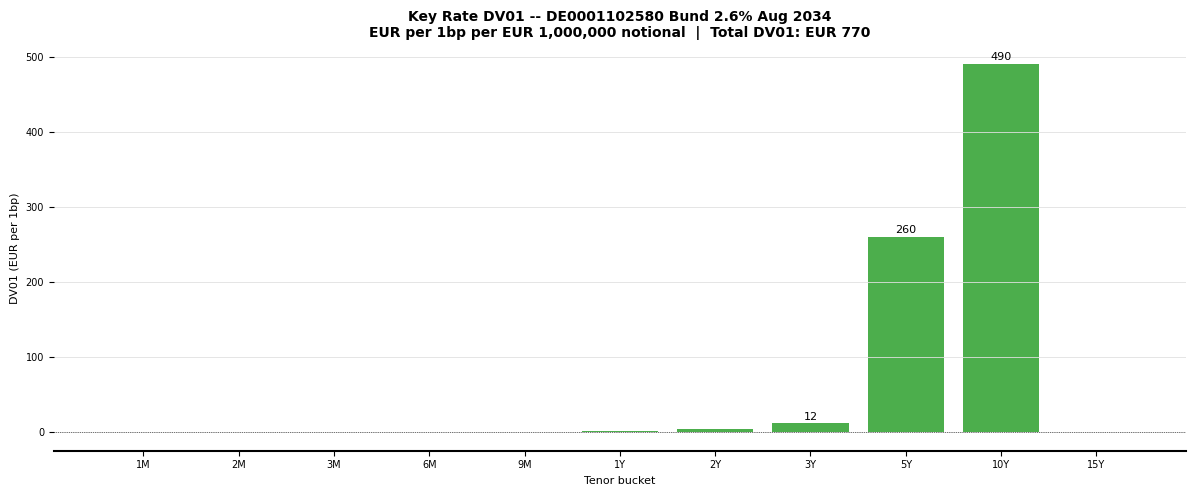

In [ ]:
# -----------------------------------------------------------------------
# bar chart
# -----------------------------------------------------------------------

kr_df = pd.DataFrame.from_dict(
    key_rate_dv01, orient="index", columns=["DV01 (EUR)"]
)
kr_df.index.name = "Tenor"

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2ca02c" if v >= 0 else "#d62728" for v in kr_df["DV01 (EUR)"]]
bars   = ax.bar(kr_df.index, kr_df["DV01 (EUR)"], color=colors, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_ylabel("DV01 (EUR per 1bp)")
ax.set_xlabel("Tenor bucket")
ax.set_title(
    f"Key Rate DV01 -- DE0001102580 Bund {coupon_rate}% Aug 2034\n"
    f"EUR per 1bp per EUR {face_value:,.0f} notional  |  "
    f"Total DV01: EUR {sum(key_rate_dv01.values()):,.0f}",
    fontweight="bold"
)

for bar, val in zip(bars, kr_df["DV01 (EUR)"]):
    if abs(val) > 5:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f"{val:,.0f}",
                ha="center", va="bottom", fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()